In [103]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [89]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [90]:
words = open("names.txt", "r").read().splitlines()

In [91]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [92]:
vocab_size = len(stoi)

In [93]:
block_size = 3

def prepare_data(words):
    X,Y = [], []
    for word in words:
        context = [0] * block_size
        for char in word:
            X.append(context)
            Y.append(stoi[char])

            context = context[1:] + [stoi[char]]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(47)
random.shuffle(words)
n1 = int(0.8 * len(words))

Xtr, Ytr = prepare_data(words[:n1])
Xtes, Ytes = prepare_data(words[n1:])

In [94]:
Xtr[0], Ytr[0]

(tensor([0, 0, 0]), tensor(11))

In [130]:
emb_dim = 3
n1 = 100
n2 = 27

epochs = 200000
batch_size = 32
lr = 0.1

In [155]:
C = torch.randn(vocab_size, emb_dim)

#layer_1
w1 = torch.randn(block_size * emb_dim, n1) *     ((5/3) / (block_size * emb_dim)**0.5)
b1 = torch.randn(n1)                            * 0.01

#layer_2
w2 = torch.randn(n1, n2)                        * 0.01
b2 = torch.randn(n2)                            * 0         # to push the initial poutputs towards more 0

parameters = [C, w1, b1, w2, b2]

for p in parameters:
    p.requires_grad = True

In [156]:
lossies = []
for epoch in range(epochs):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    # print(ix.shape)
    x,y = Xtr[ix], Ytr[ix]

    #lookup
    emb = C[x]
    # print(emb.shape)
    formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
    # print(formatted_input)

    #layer_1
    hreact = formatted_input @ w1 + b1
    h = torch.tanh(hreact)

    #layer_2
    logits = h @ w2 + b2

    #softmax
    logit_max = logits.max()
    logits = logits - logit_max
    logits_exp = logits.exp()
    logits_exp_sum = logits_exp.sum()
    probs = logits_exp/logits_exp_sum

    #loss
    # print(y)
    loss = -probs[torch.arange(batch_size), y].log().mean()
    lossies.append(loss.item())
    
    #update_grad
    for p in parameters:
        p.grad = None
    
    #backward_prop
    loss.backward()

    #update parameters
    for p in parameters:
        p.data += -lr * p.grad


(array([  2.,   1.,   1.,   1.,   1.,   0.,   1.,   3.,   1.,   2.,   9.,
          7.,  11.,  11.,  20.,  31.,  37.,  52.,  71., 100.,  94., 107.,
        128., 130., 182., 188., 250., 225., 223., 198., 202., 160., 151.,
        112., 126., 104.,  50.,  44.,  38.,  26.,  20.,  27.,  19.,  17.,
          6.,   4.,   4.,   1.,   1.,   1.]),
 array([-16.09331703, -15.50226351, -14.91120998, -14.32015646,
        -13.72910294, -13.13804941, -12.54699589, -11.95594236,
        -11.36488884, -10.77383532, -10.18278179,  -9.59172827,
         -9.00067474,  -8.40962122,  -7.8185677 ,  -7.22751417,
         -6.63646065,  -6.04540712,  -5.4543536 ,  -4.86330008,
         -4.27224655,  -3.68119303,  -3.0901395 ,  -2.49908598,
         -1.90803246,  -1.31697893,  -0.72592541,  -0.13487188,
          0.45618164,   1.04723516,   1.63828869,   2.22934221,
          2.82039574,   3.41144926,   4.00250278,   4.59355631,
          5.18460983,   5.77566336,   6.36671688,   6.9577704 ,
          7.548823

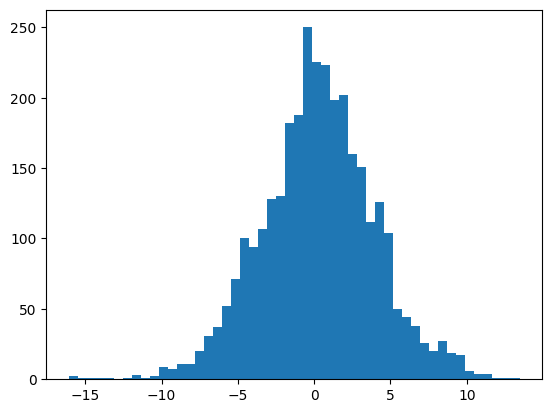

In [157]:
plt.hist(hreact.view(-1).tolist(),50)

(array([  1.,   0.,   0.,   0.,   0.,   5.,   4.,   5.,   4.,   7.,  21.,
         20.,  25.,  72.,  54.,  52.,  98.,  62., 133., 105., 134., 125.,
        136., 154., 119., 141., 175., 155., 142., 142., 149., 105., 113.,
        132., 105., 124.,  72.,  77.,  50.,  43.,  41.,  18.,  25.,  15.,
         12.,  10.,   8.,   7.,   1.,   2.]),
 array([-0.80562925, -0.77668799, -0.74774673, -0.71880547, -0.68986421,
        -0.66092295, -0.63198169, -0.60304043, -0.57409917, -0.54515791,
        -0.51621665, -0.48727539, -0.45833413, -0.42939287, -0.40045161,
        -0.37151034, -0.34256908, -0.31362782, -0.28468656, -0.2557453 ,
        -0.22680404, -0.19786278, -0.16892152, -0.13998026, -0.111039  ,
        -0.08209774, -0.05315648, -0.02421522,  0.00472604,  0.0336673 ,
         0.06260856,  0.09154982,  0.12049109,  0.14943235,  0.17837361,
         0.20731487,  0.23625613,  0.26519739,  0.29413865,  0.32307991,
         0.35202117,  0.38096243,  0.40990369,  0.43884495,  0.46778621,
 

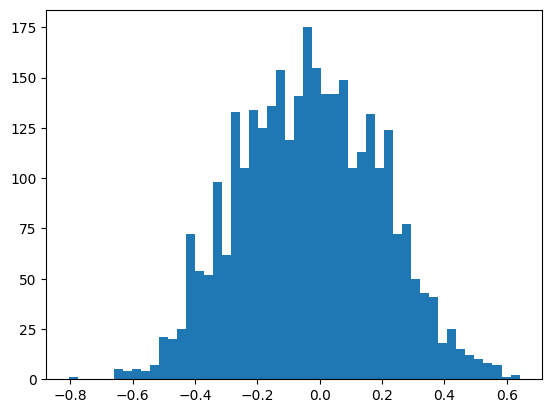

In [141]:
plt.hist(h.view(-1).tolist(),50)

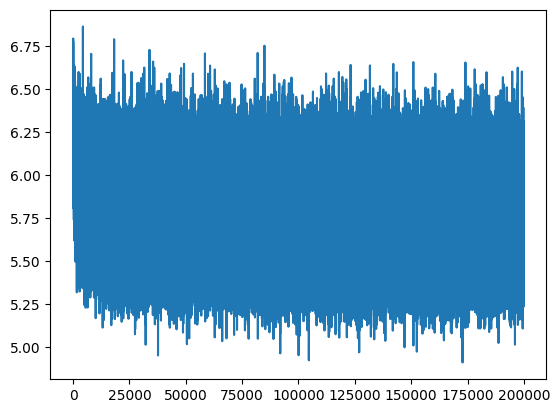

In [158]:
plt.plot(torch.arange(epochs), lossies)

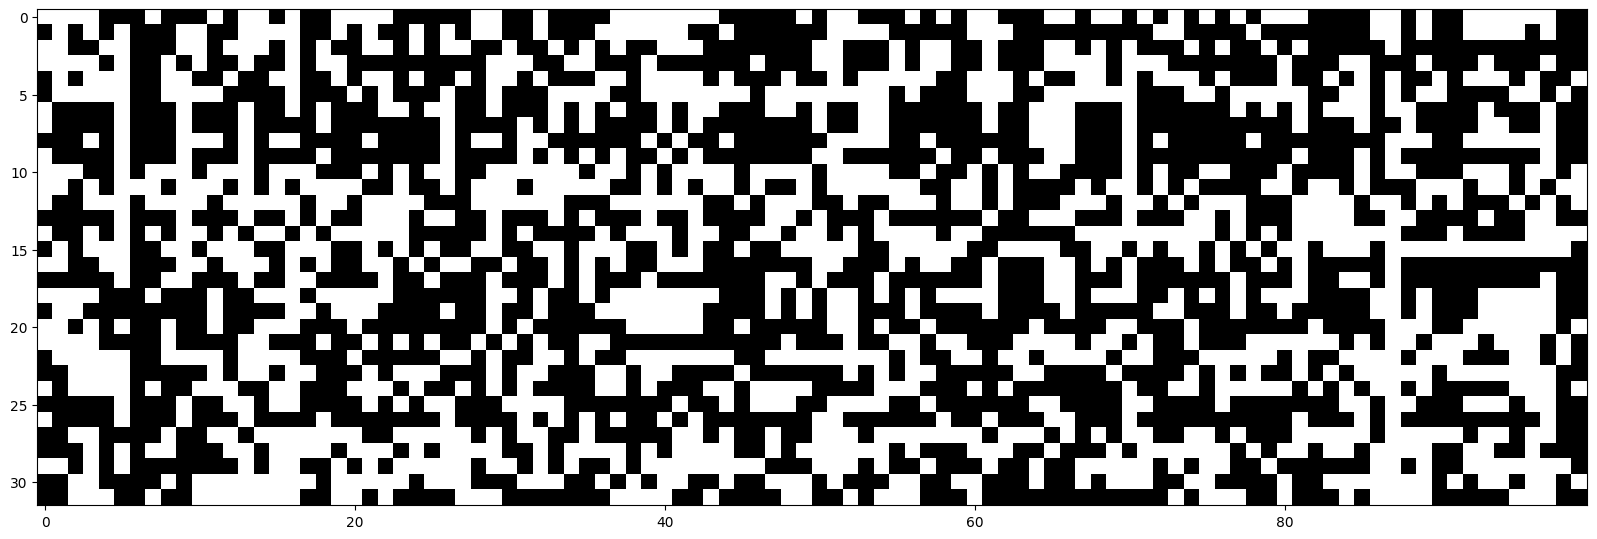

In [159]:
plt.figure(figsize=(20,50))
plt.imshow(h.abs().cpu().detach() > 0.99, cmap='gray', interpolation='nearest')

In [160]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'test': (Xtes, Ytes)
    }[split]
    emb = C[x]
    formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
    h1 = formatted_input @ w1 + b1 
    # h1 = bngain * (h1 - h1.mean(0, keepdim=True)) / (h1.std(0, keepdim=True) + 1e-5) + bnbias  # LayerNorm
    # h1 = bngain * (h1 - bnmean_running) / (bnstd_running + 1e-5) + bnbias  # LayerNorm
    h1 = torch.tanh(h1)
    logits = h1 @ w2 + b2
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')


train loss: 2.2733


In [ ]:
#original code
# loss = 2.3303

#after layer_2 weight initialization imporvement
# loss = 2.2772

# after improving tanh inputs through weight initialization in layer1
# loss = 2.2644

# after dividing w1 with square root of fan in
# loss = 2.2578

#after introducing gain
# loss = 2.2733

In [ ]:
# Reason for multiplication of w2*0.01 and b2*0
# Logits ko initially chhota rakhna chahte hain taaki softmax roughly uniform distribution de:
# b2 * 0 — Zero Bias
# Output layer ka bias zero se start karna safe hai kyunki:

# Weights already small hain (* 0.01)
# Koi ek class ko favor nahi karna start mein
# Network ko data se seekhne dena hai — not from init


# ⚠️ Disclaimer — w2 * 0 Kyun Nahi?
# Symmetry problem — backprop mein har neuron ka gradient identical hoga. Saare weights same direction mein update honge — network ki capacity destroy ho jaati hai. Yeh "dead network" problem hai.